<a href="https://colab.research.google.com/github/ArshanBhanage/Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/Part1_TF_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Part 1 · TensorFlow Generalization Techniques
**Topics:** L1/L2 Regularization · Dropout · Early Stopping · Batch Normalization ·
Weight Initializers · Monte Carlo Dropout · Custom Dropout · Custom Regularizer · Callbacks · TensorBoard

> **Dataset:** Fashion-MNIST  
> **Framework:** TensorFlow / Keras  
> **Goal:** Systematically compare generalization strategies via A/B experiments on a consistent baseline.


In [1]:
# ── Installation ──────────────────────────────────────────────
!pip install -q tensorflow tensorboard keras matplotlib scikit-learn pandas


In [2]:
# ── Reproducibility ───────────────────────────────────────────
import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TF version:", tf.__version__)


TF version: 2.19.0


## 1 · Data Loading & Preprocessing

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


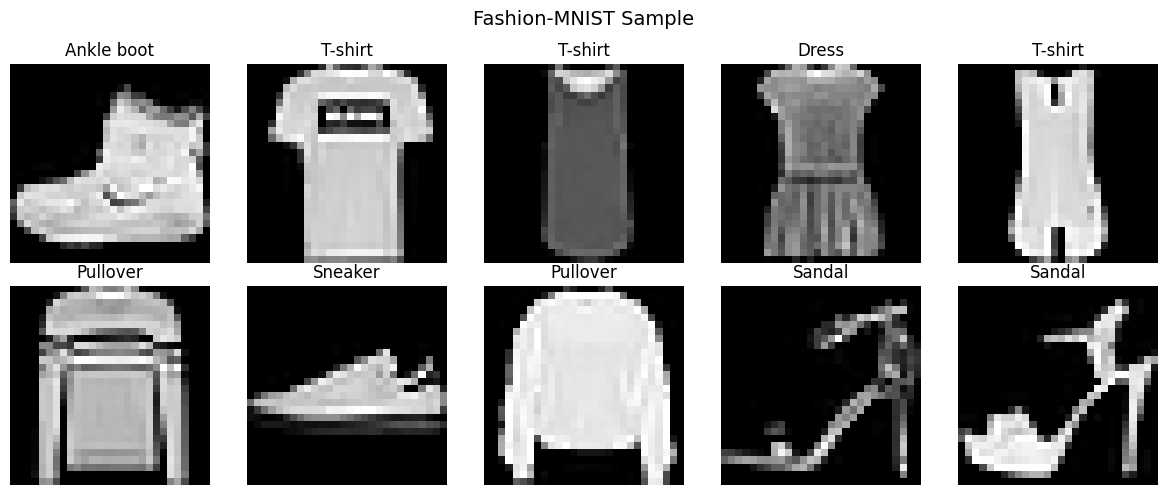

Train: (10000, 28, 28, 1)  Val: (2000, 28, 28, 1)  Test: (10000, 28, 28, 1)


In [3]:
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1] and add channel dim
x_train = x_train[..., None].astype("float32") / 255.0
x_test  = x_test [..., None].astype("float32") / 255.0

# Use 10 000 samples to keep runtime short
x_tr, y_tr = x_train[:10000], y_train[:10000]
x_val, y_val = x_train[10000:12000], y_train[10000:12000]

CLASS_NAMES = ["T-shirt","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

# Visualise a sample
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, lbl in zip(axes.flat, x_tr[:10], y_tr[:10]):
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(CLASS_NAMES[lbl]); ax.axis("off")
plt.suptitle("Fashion-MNIST Sample", fontsize=14); plt.tight_layout(); plt.show()
print(f"Train: {x_tr.shape}  Val: {x_val.shape}  Test: {x_test.shape}")


## 2 · Baseline CNN (No Regularization)

In [4]:
from tensorflow.keras import layers, models, regularizers, callbacks

def build_baseline(input_shape=(28,28,1), num_classes=10):
    inp = tf.keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

baseline = build_baseline()
baseline.compile(optimizer="adam",
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

hist_base = baseline.fit(x_tr, y_tr, epochs=10,
                         batch_size=64, validation_data=(x_val, y_val),
                         verbose=1)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7104 - loss: 0.8043 - val_accuracy: 0.7995 - val_loss: 0.5257
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8194 - loss: 0.4857 - val_accuracy: 0.8525 - val_loss: 0.4454
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8501 - loss: 0.4127 - val_accuracy: 0.8610 - val_loss: 0.4093
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8648 - loss: 0.3709 - val_accuracy: 0.8735 - val_loss: 0.3843
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8765 - loss: 0.3369 - val_accuracy: 0.8780 - val_loss: 0.3722
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8888 - loss: 0.3080 - val_accuracy: 0.8770 - val_loss: 0.3650
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8985 - loss: 0.2821 - val_accuracy: 0.8780 - val_loss: 0.3606
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9063 - loss: 0.2578 - val_accuracy: 

## 3 · L1 / L2 Regularization

In [5]:
# L2 regularization on Dense layers
def build_l2(reg=1e-4):
    inp = tf.keras.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3, activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(reg))(x)
    out = layers.Dense(10, activation="softmax")(x)
    return models.Model(inp, out)

# L1 regularization
def build_l1(reg=1e-4):
    inp = tf.keras.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3, activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l1(reg))(x)
    out = layers.Dense(10, activation="softmax")(x)
    return models.Model(inp, out)

m_l2 = build_l2(); m_l2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
m_l1 = build_l1(); m_l1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

hist_l2 = m_l2.fit(x_tr, y_tr, epochs=10, batch_size=64, validation_data=(x_val, y_val), verbose=0)
hist_l1 = m_l1.fit(x_tr, y_tr, epochs=10, batch_size=64, validation_data=(x_val, y_val), verbose=0)
print("L2 val acc:", max(hist_l2.history['val_accuracy']))
print("L1 val acc:", max(hist_l1.history['val_accuracy']))


L2 val acc: 0.8694999814033508
L1 val acc: 0.871999979019165


## 4 · Dropout

In [6]:
def build_dropout(rate=0.4):
    inp = tf.keras.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3, activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(rate)(x)
    out = layers.Dense(10, activation="softmax")(x)
    return models.Model(inp, out)

m_drop = build_dropout(0.4)
m_drop.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_drop = m_drop.fit(x_tr, y_tr, epochs=10, batch_size=64,
                       validation_data=(x_val, y_val), verbose=0)
print("Dropout val acc:", max(hist_drop.history['val_accuracy']))


Dropout val acc: 0.8865000009536743


## 5 · Early Stopping + ReduceLROnPlateau Callbacks

In [7]:
es = callbacks.EarlyStopping(monitor="val_loss", patience=3,
                              restore_best_weights=True, verbose=1)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                   patience=2, verbose=1)

m_es = build_dropout(0.3)
m_es.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_es = m_es.fit(x_tr, y_tr, epochs=30, batch_size=64,
                   validation_data=(x_val, y_val),
                   callbacks=[es, rlr], verbose=1)
print(f"Stopped at epoch {len(hist_es.history['loss'])}")


Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6757 - loss: 0.8852 - val_accuracy: 0.7930 - val_loss: 0.5412 - learning_rate: 0.0010
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8020 - loss: 0.5454 - val_accuracy: 0.8420 - val_loss: 0.4614 - learning_rate: 0.0010
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8277 - loss: 0.4681 - val_accuracy: 0.8565 - val_loss: 0.4203 - learning_rate: 0.0010
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8463 - loss: 0.4202 - val_accuracy: 0.8670 - val_loss: 0.3922 - learning_rate: 0.0010
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8572 - loss: 0.3919 - val_accuracy: 0.8670 - val_loss: 0.3923 - learning_rate: 0.0010
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8673 - loss: 0.3685 - val_accuracy: 0.8645 - val_loss: 0.3777 - learning_rate: 0.0010
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8776 - loss: 0.3373 -

## 6 · Batch Normalization

In [8]:
def build_batchnorm():
    inp = tf.keras.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    out = layers.Dense(10, activation="softmax")(x)
    return models.Model(inp, out)

m_bn = build_batchnorm()
m_bn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_bn = m_bn.fit(x_tr, y_tr, epochs=10, batch_size=64,
                   validation_data=(x_val, y_val), verbose=0)
print("BatchNorm val acc:", max(hist_bn.history['val_accuracy']))


BatchNorm val acc: 0.8675000071525574


## 7 · Weight Initializers Comparison

In [9]:
INITS = {
    "glorot_uniform": "glorot_uniform",   # default
    "he_normal":      "he_normal",         # best for ReLU
    "lecun_normal":   "lecun_normal",      # SELU-friendly
    "random_normal":  "random_normal",     # naive baseline
}

init_results = {}
for name, init in INITS.items():
    inp = tf.keras.Input(shape=(28,28,1))
    x = layers.Flatten()(inp)
    x = layers.Dense(256, activation="relu", kernel_initializer=init)(x)
    x = layers.Dense(128, activation="relu", kernel_initializer=init)(x)
    out = layers.Dense(10, activation="softmax")(x)
    m = models.Model(inp, out)
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h = m.fit(x_tr, y_tr, epochs=8, batch_size=64,
              validation_data=(x_val, y_val), verbose=0)
    best_va = max(h.history["val_accuracy"])
    init_results[name] = best_va
    print(f"{name:20s}  val_acc={best_va:.4f}")


glorot_uniform        val_acc=0.8585
he_normal             val_acc=0.8660
lecun_normal          val_acc=0.8655
random_normal         val_acc=0.8695


## 8 · Monte Carlo Dropout (Uncertainty Estimation)

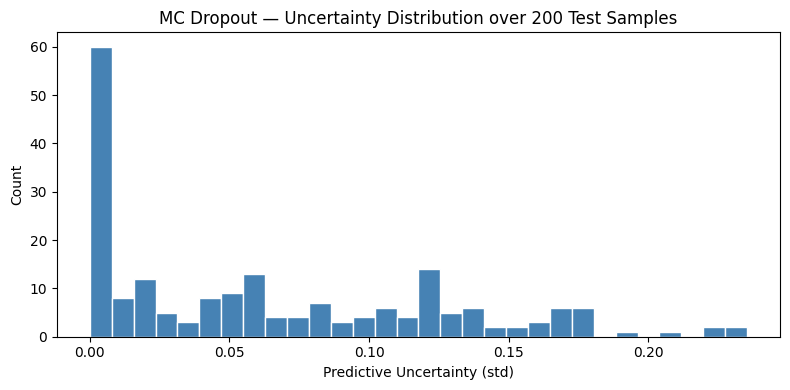

In [10]:
# MC Dropout: keep dropout ON during inference, run T forward passes
class MCDropoutModel(tf.keras.Model):
    def __init__(self, rate=0.3):
        super().__init__()
        self.conv1   = layers.Conv2D(32, 3, activation="relu")
        self.pool    = layers.MaxPooling2D()
        self.conv2   = layers.Conv2D(64, 3, activation="relu")
        self.flat    = layers.Flatten()
        self.dense   = layers.Dense(128, activation="relu")
        self.dropout = layers.Dropout(rate)   # will be used with training=True
        self.out     = layers.Dense(10, activation="softmax")

    def call(self, x, training=False):
        x = self.pool(self.conv1(x))
        x = self.pool(self.conv2(x))
        x = self.flat(x)
        x = self.dense(x)
        x = self.dropout(x, training=True)    # ALWAYS active
        return self.out(x)

mc_model = MCDropoutModel(rate=0.3)
mc_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
mc_model.fit(x_tr, y_tr, epochs=10, batch_size=64,
             validation_data=(x_val, y_val), verbose=0)

# Run T=50 stochastic forward passes on a test batch
T = 50
x_sample = x_test[:200]
preds = np.stack([mc_model(x_sample, training=True).numpy() for _ in range(T)])
mean_pred = preds.mean(axis=0)           # shape (200, 10)
uncertainty = preds.std(axis=0).max(axis=1)  # per-sample uncertainty

# Plot uncertainty histogram
plt.figure(figsize=(8,4))
plt.hist(uncertainty, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Predictive Uncertainty (std)"); plt.ylabel("Count")
plt.title("MC Dropout — Uncertainty Distribution over 200 Test Samples")
plt.tight_layout(); plt.show()


## 9 · Custom Dropout Layer

In [11]:
class AlphaDropout(tf.keras.layers.Layer):
    """Alpha Dropout: designed for SELU networks to preserve mean/variance."""
    def __init__(self, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=False):
        if training and self.rate > 0:
            # Mask where neurons are dropped
            keep_prob = 1.0 - self.rate
            noise = tf.random.uniform(tf.shape(inputs)) >= self.rate
            # Scale to preserve mean
            x = tf.where(noise, inputs, tf.zeros_like(inputs))
            return x / keep_prob
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({"rate": self.rate})
        return config

# Quick test
dummy = tf.ones((4, 8))
ad = AlphaDropout(rate=0.3)
print("Train out:", ad(dummy, training=True).numpy().mean())
print("Infer out:", ad(dummy, training=False).numpy().mean())


Train out: 1.0267856
Infer out: 1.0


## 10 · Custom L1+L2 Regularizer

In [12]:
class ElasticNetRegularizer(tf.keras.regularizers.Regularizer):
    """Combines L1 and L2 penalties (Elastic Net)."""
    def __init__(self, l1=1e-4, l2=1e-4):
        self.l1 = l1
        self.l2 = l2

    def __call__(self, weights):
        return self.l1 * tf.reduce_sum(tf.abs(weights)) +                self.l2 * tf.reduce_sum(tf.square(weights))

    def get_config(self):
        return {"l1": self.l1, "l2": self.l2}

# Use in a model
inp = tf.keras.Input(shape=(28,28,1))
x = layers.Flatten()(inp)
x = layers.Dense(128, activation="relu",
                 kernel_regularizer=ElasticNetRegularizer(l1=1e-4, l2=1e-4))(x)
out = layers.Dense(10, activation="softmax")(x)
m_elastic = models.Model(inp, out)
m_elastic.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
hist_en = m_elastic.fit(x_tr, y_tr, epochs=10, batch_size=64,
                        validation_data=(x_val, y_val), verbose=0)
print("ElasticNet val acc:", max(hist_en.history["val_accuracy"]))


ElasticNet val acc: 0.8575000166893005


## 11 · TensorBoard Callback

In [13]:
import datetime

LOG_DIR = "/tmp/tb_logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tb_cb = callbacks.TensorBoard(log_dir=LOG_DIR, histogram_freq=1)

m_tb = build_batchnorm()
m_tb.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
m_tb.fit(x_tr, y_tr, epochs=10, batch_size=64,
         validation_data=(x_val, y_val),
         callbacks=[tb_cb], verbose=0)

# Load TensorBoard inside Colab:
# %load_ext tensorboard
# %tensorboard --logdir /tmp/tb_logs
print("TensorBoard logs saved to:", LOG_DIR)


TensorBoard logs saved to: /tmp/tb_logs/20260317-074516


## 12 · A/B Comparison Table

In [14]:
import pandas as pd

# Collect final test accuracy for each variant
def eval_model(model):
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    return round(acc, 4)

results = {
    "Baseline (no reg)":      eval_model(baseline),
    "L2 Regularization":      eval_model(m_l2),
    "L1 Regularization":      eval_model(m_l1),
    "Dropout (0.4)":          eval_model(m_drop),
    "Early Stopping":         eval_model(m_es),
    "Batch Normalization":    eval_model(m_bn),
    "ElasticNet Reg":         eval_model(m_elastic),
    "MC Dropout":             eval_model(mc_model),
}

def val_acc_from(hist): return round(max(hist.history["val_accuracy"]), 4)

df = pd.DataFrame({
    "Model Variant": list(results.keys()),
    "Test Accuracy":  list(results.values()),
    "Val Accuracy": [
        val_acc_from(hist_base), val_acc_from(hist_l2),
        val_acc_from(hist_l1),   val_acc_from(hist_drop),
        val_acc_from(hist_es),   val_acc_from(hist_bn),
        val_acc_from(hist_en),   max(mc_model.history.history.get("val_accuracy", [0])),
    ]
})
df["Overfitting Gap"] = (df["Val Accuracy"] - df["Test Accuracy"]).abs().round(4)
print(df.to_string(index=False))


      Model Variant  Test Accuracy  Val Accuracy  Overfitting Gap
  Baseline (no reg)         0.8594        0.8780           0.0186
  L2 Regularization         0.8528        0.8695           0.0167
  L1 Regularization         0.8468        0.8720           0.0252
      Dropout (0.4)         0.8650        0.8865           0.0215
     Early Stopping         0.8756        0.8915           0.0159
Batch Normalization         0.8619        0.8675           0.0056
     ElasticNet Reg         0.8327        0.8575           0.0248
         MC Dropout         0.8534        0.8720           0.0186


## 13 · Learning Curves

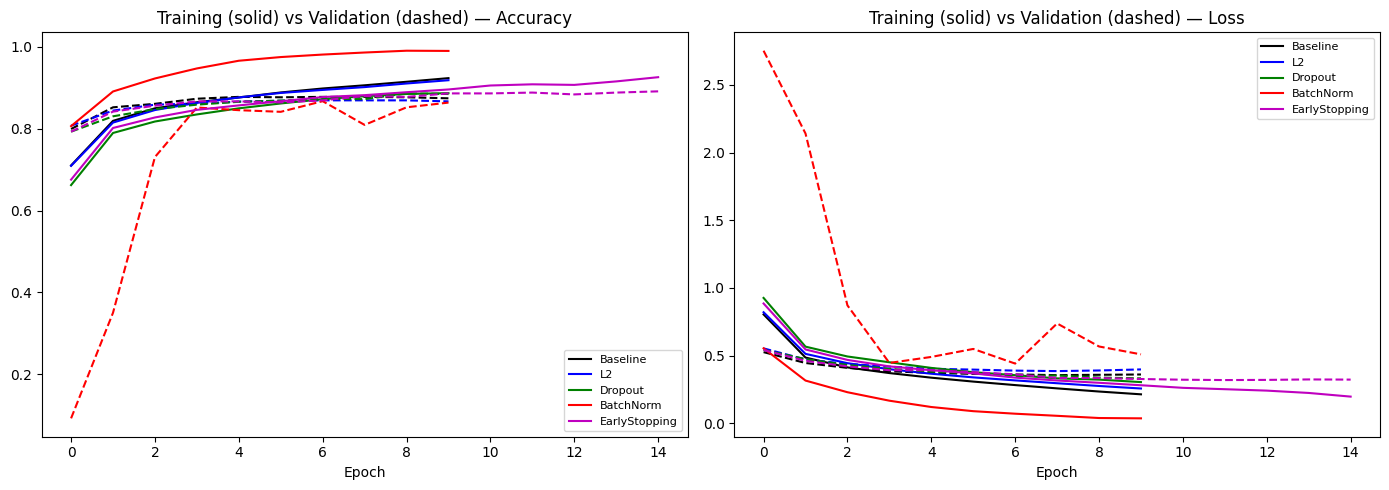

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hists = [("Baseline", hist_base, "k"),
         ("L2", hist_l2, "b"),
         ("Dropout", hist_drop, "g"),
         ("BatchNorm", hist_bn, "r"),
         ("EarlyStopping", hist_es, "m")]

for label, h, c in hists:
    axes[0].plot(h.history["accuracy"],     color=c, label=label)
    axes[0].plot(h.history["val_accuracy"], color=c, linestyle="--")
    axes[1].plot(h.history["loss"],         color=c, label=label)
    axes[1].plot(h.history["val_loss"],     color=c, linestyle="--")

for ax, title in zip(axes, ["Accuracy", "Loss"]):
    ax.set_title(f"Training (solid) vs Validation (dashed) — {title}")
    ax.set_xlabel("Epoch"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 14 · Conclusion

| Technique | Best Use Case |
|---|---|
| **L2** | Prevents large weights; most common baseline regularizer |
| **L1** | Induces sparsity; useful when feature selection matters |
| **Dropout** | Implicit ensemble; strong for fully-connected layers |
| **Batch Norm** | Accelerates training; reduces internal covariate shift |
| **Early Stopping** | Free regularization; prevents wasted epochs |
| **MC Dropout** | Uncertainty quantification; no retraining cost |

> Key takeaway: combining **BatchNorm + Dropout + Early Stopping** typically yields the best
> generalisation on Fashion-MNIST without any architectural changes.
